## Дз 2. Аналоговые фильтры
**Вариант 2. Бакулев Семён**

$$
x(t)=
\frac{a_2}{b_2 + \left|t - t_2\right|}
\exp\!\left(-c_2 \left|t - t_3\right|\right)
\,\mathrm{sinc}(d_2 t)
$$

Параметры:
```
a2 = -5
b2 =  2
t2 = -2
c2 =  0.4
t3 = -1
d2 =  9
```

## Идеальный полосовой фильтр
Его цель — удаление из сигнала ярко выраженных колебаний.

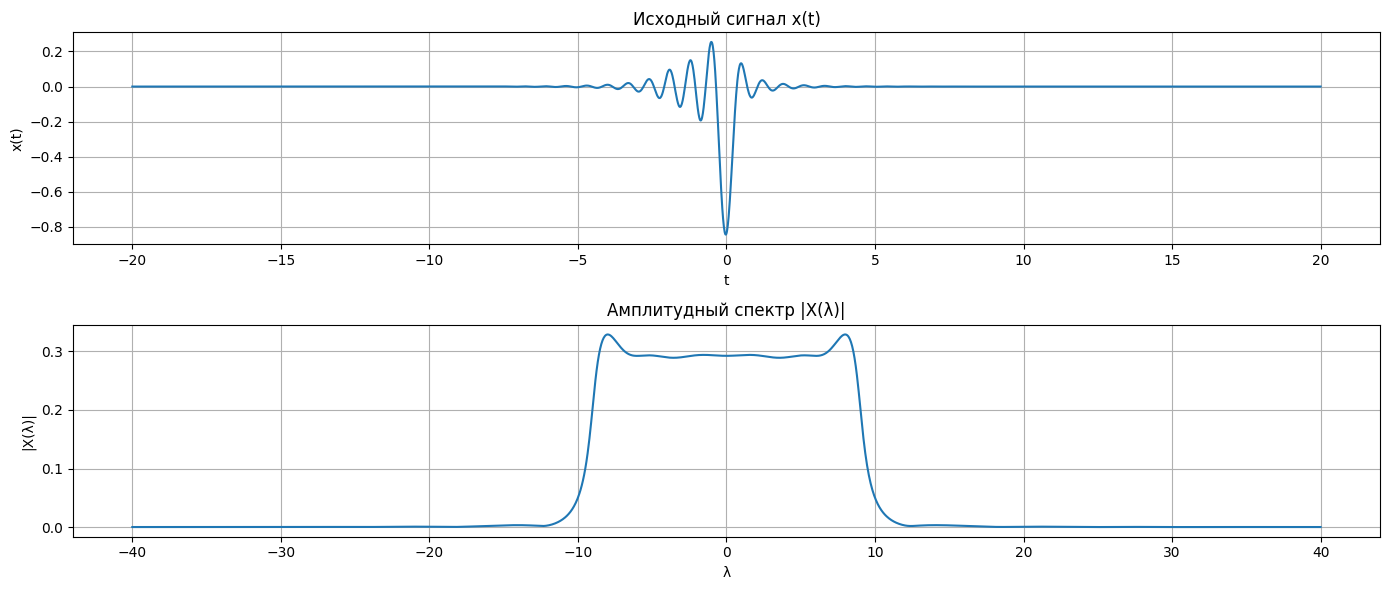

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры сигнала
a2 = -5
b2 = 2
t2 = -2
c2 = 0.4
t3 = -1
d2 = 9


# Функция сигнала
def x(t):
    return (
        (a2 / (b2 + np.abs(t - t2)))
        * np.exp(-c2 * np.abs(t - t3))
        * np.sinc(d2 * t / np.pi)
    )

t_min, t_max = -20, 20
lambda_min = -40
lambda_max = 40

N = 3000
M = 2000
# Сетка по времени
t = np.linspace(t_min, t_max, N)
dt = t[1] - t[0]

x_vals = x(t)

plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(t, x_vals, label="Исходный сигнал")
plt.title("Исходный сигнал x(t)")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)

lambdas = np.linspace(lambda_min, lambda_max, M)

E_forward = np.exp(-1j * np.outer(lambdas, t))  # M x N
X_vals = E_forward @ x_vals * dt  # M

plt.subplot(2, 1, 2)
plt.plot(lambdas, np.abs(X_vals))
plt.title("Амплитудный спектр |X(λ)|")
plt.xlabel("λ")
plt.ylabel("|X(λ)|")
plt.grid(True)

plt.tight_layout()
plt.show()

В исходном сигнале колбеания задаются компонентой $\mathrm{sinc}(9t)$, поэтому "осцилирующая" часть связана с частотами порядка $|\lambda|≈9$. По графику амплитудного спектра для этого сигнала наиболее заметные пики действительно оказываются около $λ≈\pm8...\pm9$, поэтому возьмём полосу пропускания чуть уже, чем эти частоты, например: $[−λ_F​,λ_F​]=[−6,6]$, чтобы отбросить эти выраженные пики.

#### Фильтрция через ПФ (идея)
1. Находим спектр сигнала
2. Умножаем на фильтр
3. Делаем обратное ПФ, чтобы получить новый сигнал
#### Фильтрция через свёртку (идея)
Фильтр действует во времени, каждая точка сигнала получается как “смешивание” соседних значений.

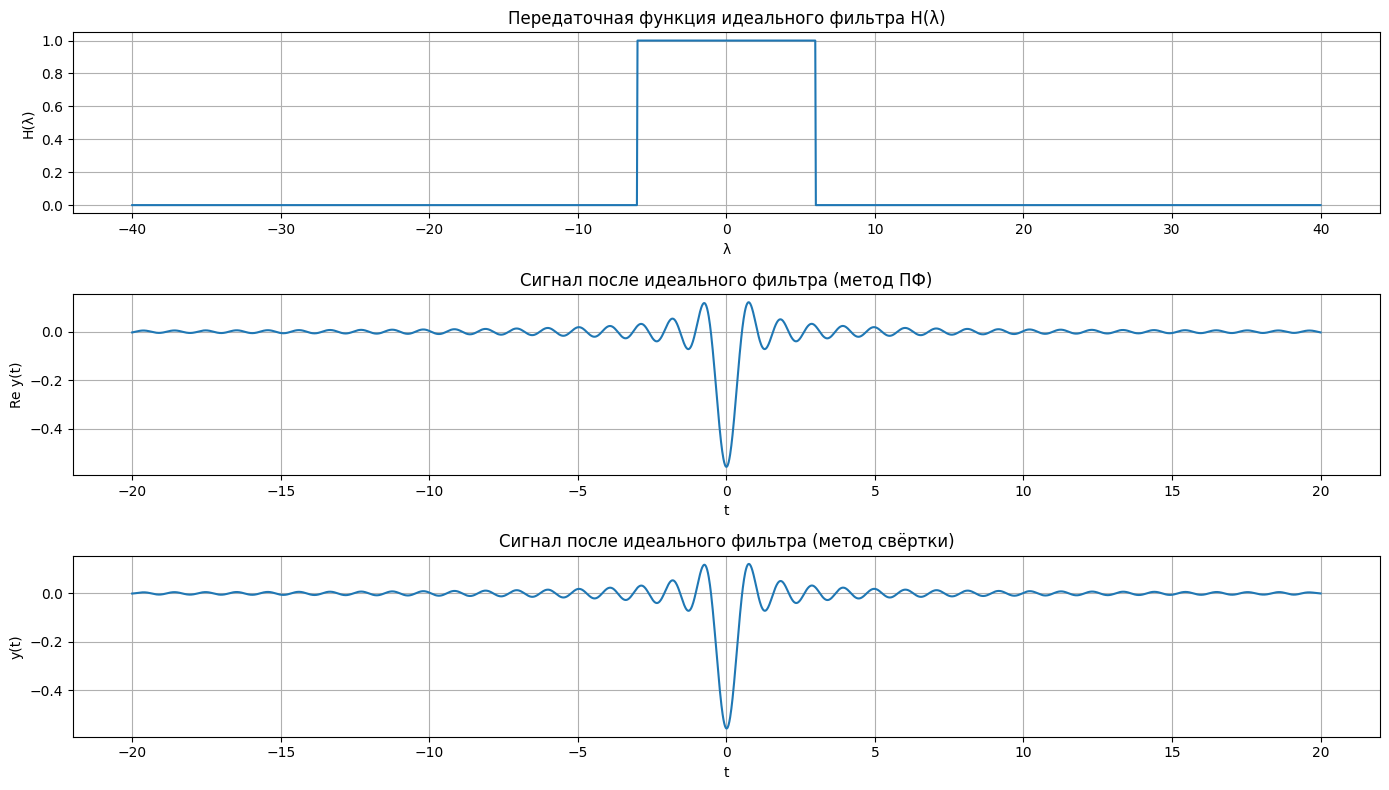

In [70]:
lambda_F = 6.0
H = np.where(np.abs(lambdas) <= lambda_F, 1.0, 0.0)

plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
plt.plot(lambdas, H)
plt.title("Передаточная функция идеального фильтра H(λ)")
plt.xlabel("λ")
plt.ylabel("H(λ)")
plt.grid(True)

Y = X_vals * H

dt = t[1] - t[0]
dlambdas = lambdas[1] - lambdas[0]

E_inverse = np.exp(1j * np.outer(t, lambdas))  # N x M
y_fourier = (E_inverse @ Y) * dlambdas / (2 * np.pi)

def h_ideal(t, lam_F):
    h = np.empty_like(t)
    mask = np.abs(t) > 1e-12
    h[mask] = np.sin(lam_F * t[mask]) / (np.pi * t[mask])
    h[~mask] = lam_F / np.pi
    return h


h_vals = h_ideal(t, lambda_F)

plt.subplot(3, 1, 2)
plt.plot(t, np.real(y_fourier), label="После фильтра (через ПФ)")
plt.title("Сигнал после идеального фильтра (метод ПФ)")
plt.xlabel("t")
plt.ylabel("Re y(t)")
plt.grid(True)

y_conv_full = dt * np.convolve(x_vals, h_vals, mode="same")
plt.subplot(3, 1, 3)
plt.plot(t, y_conv_full, label="После фильтра (через свёртку)")
plt.title("Сигнал после идеального фильтра (метод свёртки)")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid(True)

plt.tight_layout()
plt.show()

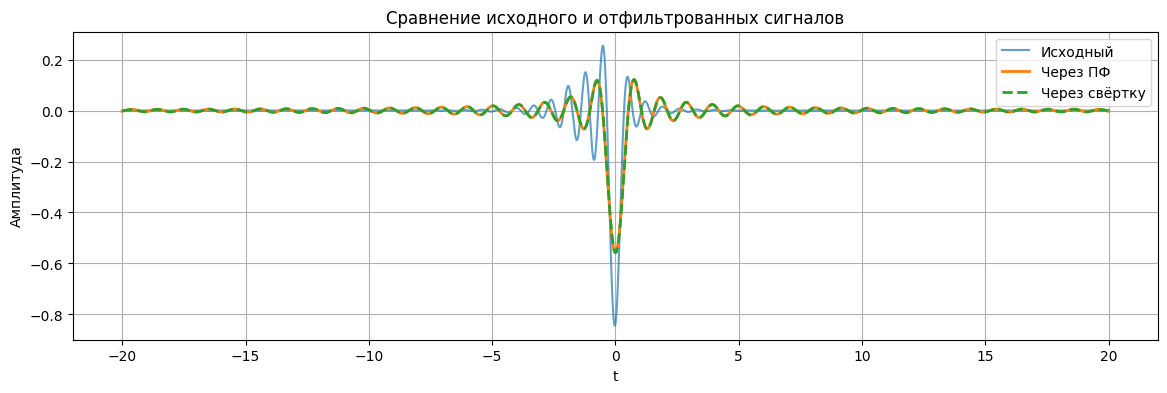

In [71]:
plt.figure(figsize=(14, 4))
plt.plot(t, x_vals, label="Исходный", alpha=0.7)
plt.plot(t, np.real(y_fourier), label="Через ПФ", linewidth=2)
plt.plot(t, y_conv_full, "--", label="Через свёртку", linewidth=2)
plt.title("Сравнение исходного и отфильтрованных сигналов")
plt.xlabel("t")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

In [69]:
mae_vs_original = np.mean(np.abs(np.real(y_fourier) - x_vals))
maxdiff_methods = np.max(np.abs(np.real(y_fourier) - y_conv_full))
mae_methods = np.mean(np.abs(np.real(y_fourier) - y_conv_full))

print("Параметры расчета:")
print(f"t in [{t_min}, {t_max}], λ in [{lambda_min}, {lambda_max}]")
print(f"N = {N}, M = {M}, Δt = {dt}, Δλ = {dlambdas}")
print(f"Выбранная полоса пропускания: [-{lambda_F}, {lambda_F}]")

print("\nОценки:")
print(f"Среднее |y_fourier - x| = {mae_vs_original}")
print(f"Макс |y_fourier - y_conv| = {maxdiff_methods}")
print(f"Среднее |y_fourier - y_conv| = {mae_methods}")


Параметры расчета:
t in [-20, 20], λ in [-40, 40]
N = 3000, M = 2000, Δt = 0.013337779259753546, Δλ = 0.04002001000500144
Выбранная полоса пропускания: [-3.0, 3.0]

Оценки:
Среднее |y_fourier - x| = 0.021102056488166612
Макс |y_fourier - y_conv| = 0.002506972768831689
Среднее |y_fourier - y_conv| = 0.0002931524548874336


Итак, заметим, что после фильтрации методом прямого и обратного преобразования Фурье сигнал **изменился** ($|y_fourier - x|=0.019$), он стал более гладким судя по графику: быстрые осцилляции заметно подавились, при этом медленная огибающая сохранилась.
При пропускании этого же сигнала через фильтр методом свёртки с функцией отклика результат практически совпадает. Есть небольшие численные различия результатов двух методов, однако они несуществуенны (в среднем 0.00065).

Если диапазон пропускания через фильтр увеличить, например, до 11, то исходный и обработанный сигнал станут намного ближе друг к другу, однако это нецелесообразно, так как фильтр перестаёт подавлять высокочастотные компоненты сигнала. При уменьшении диапазона, например, до 3, различия будут только увеличиваться.